## Space Shuttle Launch Temperature Data

In [ ]:
import math
import pymc as pm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import arviz as az

Set style

In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

The following dataset describes the ambient temperature at the time of each Space Shuttle launch, and whether o-ring damage was observed.

In [4]:
temperature = np.array([66, 70, 69, 80, 68, 67, 72, 73, 70, 57, 63, 70, 78, 67, 53, 67, 75, 70, 81, 76, 79, 75, 76, 58])
damage = np.array([0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1])

### 1. Data Exploration

In [6]:
print(f"\nDataset Information:")
print(f"  Total launches: {len(damage)}")
print(f"  Launches with damage: {damage.sum()} ({damage.sum()/len(damage)*100:.1f}%)")
print(f"  Temperature range: {temperature.min()}°F - {temperature.max()}°F")
print(f"  Mean temperature: {temperature.mean():.1f}°F")
print(f"  Challenger temperature: 36°F")
print(f"  Extrapolation: {temperature.min()-36}°F below minimum observed")



Dataset Information:
  Total launches: 24
  Launches with damage: 7 (29.2%)
  Temperature range: 53°F - 81°F
  Mean temperature: 70.0°F
  Challenger temperature: 36°F
  Extrapolation: 17°F below minimum observed


In [ ]:
# Figure 1 - data points
plt.figure(figsize=(10, 6))
plt.scatter(temperature, damage, alpha=0.6, s=100, c=damage, cmap='RdYlGn_r',
           edgecolors='black', linewidth=1.5)
plt.xlabel('Temperature (°F)', fontsize=12)
plt.ylabel('O-ring Damage (0=No, 1=Yes)', fontsize=12)
plt.title('Historical Space Shuttle Launches: Temperature vs O-ring Damage',
          fontsize=14, fontweight='bold')
plt.axvline(x=36, color='red', linestyle='--', linewidth=2,
            label='Challenger Launch (36°F)')
plt.yticks([0, 1], ['No Damage', 'Damage'])
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('Figure1_Data_Exploration.png', dpi=300, bbox_inches='tight')
plt.show()

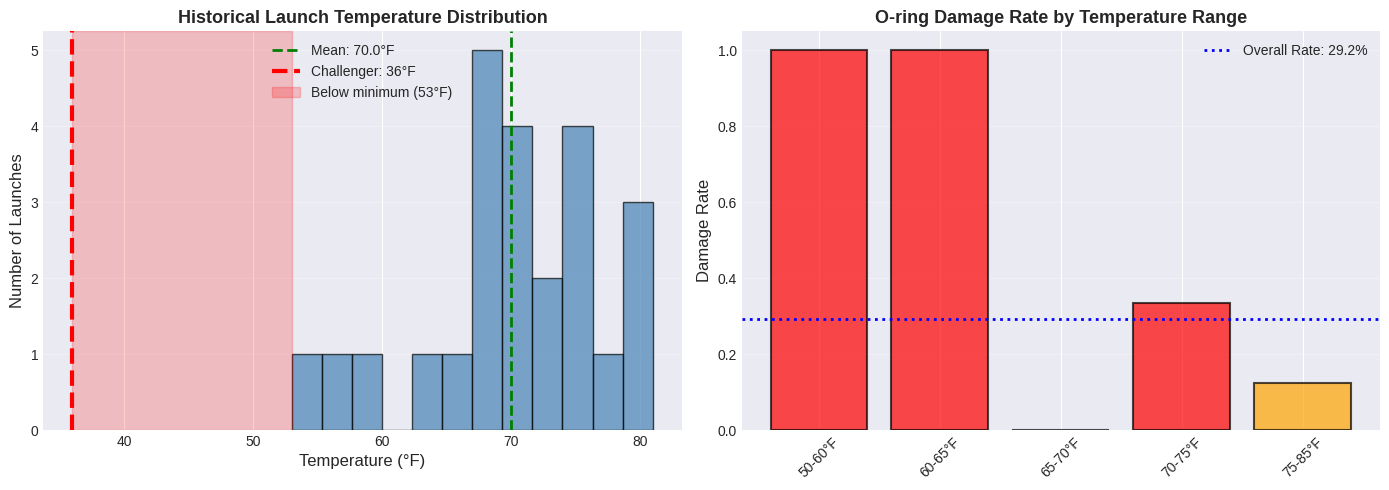

In [11]:
# Figure 2 - Temperature Distribution Histogram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Temperature distribution
ax1.hist(temperature, bins=12, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(temperature.mean(), color='green', linestyle='--', linewidth=2,
           label=f'Mean: {temperature.mean():.1f}°F')
ax1.axvline(36, color='red', linestyle='--', linewidth=3,
           label='Challenger: 36°F')
ax1.axvspan(temperature.min(), 36, alpha=0.2, color='red',
           label=f'Below minimum ({temperature.min()}°F)')
ax1.set_xlabel('Temperature (°F)', fontsize=12)
ax1.set_ylabel('Number of Launches', fontsize=12)
ax1.set_title('Historical Launch Temperature Distribution', fontweight='bold', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Right: Damage rate by temperature bins
temp_bins = [50, 60, 65, 70, 75, 85]
damage_rates = []
bin_labels = []

for i in range(len(temp_bins)-1):
    mask = (temperature >= temp_bins[i]) & (temperature < temp_bins[i+1])
    if mask.sum() > 0:
        rate = damage[mask].mean()
        damage_rates.append(rate)
        bin_labels.append(f'{temp_bins[i]}-{temp_bins[i+1]}°F')

ax2.bar(range(len(damage_rates)), damage_rates, alpha=0.7,
       color=['red' if r > 0.3 else 'orange' if r > 0.1 else 'green' for r in damage_rates],
       edgecolor='black', linewidth=1.5)
ax2.set_xticks(range(len(bin_labels)))
ax2.set_xticklabels(bin_labels, rotation=45)
ax2.set_ylabel('Damage Rate', fontsize=12)
ax2.set_title('O-ring Damage Rate by Temperature Range', fontweight='bold', fontsize=13)
ax2.axhline(damage.mean(), color='blue', linestyle=':', linewidth=2,
           label=f'Overall Rate: {damage.mean():.1%}')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
#plt.savefig('Figure2_Temperature_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### 2. Build PyMC model

In [14]:
temp_mean = temperature.mean()

with pm.Model() as model:
    # Priors
    t0 = pm.Normal('t0', mu=temp_mean, sigma=10)
    k = pm.HalfNormal('k', sigma=2)

    # Logistic function: f(t) = 1 / (1 + exp(-k(t-t0)))
    logit_p = -k * (temperature - t0)
    p = pm.Deterministic('p', pm.math.invlogit(logit_p))

    # Likelihood
    y_obs = pm.Bernoulli('y_obs', p=p, observed=damage)

print("   Model structure defined")


with model:
    initial_t0 = temp_mean
    initial_k = 0.1
    map_estimate = pm.find_MAP(start={'t0': initial_t0, 'k': initial_k})

print(f"   MAP estimates:")
print(f"     t0 = {map_estimate['t0']:.2f}°F")
print(f"     k = {map_estimate['k']:.4f}")

   Model structure defined


Output()

   MAP estimates:
     t0 = 65.15°F
     k = 0.2423


### 3. MCMC Sampling

In [15]:
with model:
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        cores=1,
        random_seed=42,
        initvals=map_estimate,
        return_inferencedata=True,
        progressbar=True
    )

print("   Sampling complete!")

# Extract posterior samples
t0_samples = trace.posterior['t0'].values.flatten()
k_samples = trace.posterior['k'].values.flatten()

print(f"\n   Posterior Summary:")
print(f"     t0: Mean = {t0_samples.mean():.2f}°F, "
      f"95% HDI = [{np.percentile(t0_samples, 2.5):.2f}, {np.percentile(t0_samples, 97.5):.2f}]")
print(f"     k:  Mean = {k_samples.mean():.4f}, "
      f"95% HDI = [{np.percentile(k_samples, 2.5):.4f}, {np.percentile(k_samples, 97.5):.4f}]")

Output()

   Sampling complete!

   Posterior Summary:
     t0: Mean = 64.53°F, 95% HDI = [56.92, 69.29]
     k:  Mean = 0.2510, 95% HDI = [0.0699, 0.5237]


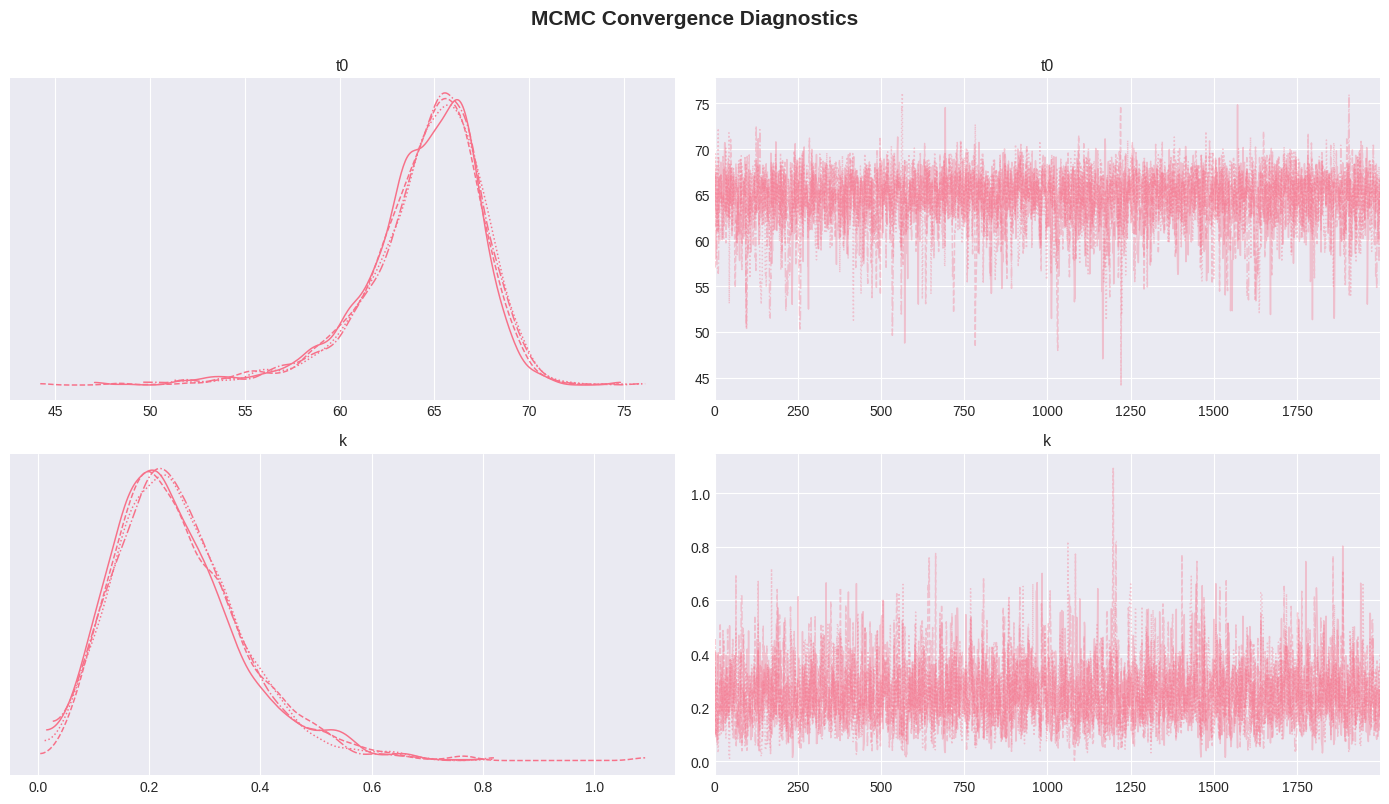

In [17]:
# Figure 2 - trace plots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
az.plot_trace(trace, var_names=['t0', 'k'], axes=axes)
plt.suptitle('MCMC Convergence Diagnostics', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
#plt.savefig('Figure3_Trace_Plots.png', dpi=300, bbox_inches='tight')
plt.show()

### 4. Prediction at 36°F

In [18]:
temp_36 = 36
logit_p_36 = -k_samples * (temp_36 - t0_samples)
p_damage_36 = 1 / (1 + np.exp(-logit_p_36))

mean_prob = p_damage_36.mean()
median_prob = np.median(p_damage_36)
hdi_low = np.percentile(p_damage_36, 2.5)
hdi_high = np.percentile(p_damage_36, 97.5)

print(f"\n   Posterior predictive probability at 36°F:")
print(f"     Mean:   {mean_prob:.4f} ({mean_prob*100:.2f}%)")
print(f"     Median: {median_prob:.4f} ({median_prob*100:.2f}%)")
print(f"     95% HDI: [{hdi_low:.4f}, {hdi_high:.4f}] ({hdi_low*100:.2f}% - {hdi_high*100:.2f}%)")

# Comparison at different temperatures
print(f"\n   Probability comparison across temperatures:")
print(f"   {'Temp (°F)':<12} {'Mean P(damage)':<18} {'95% HDI':<30}")
print("   " + "-" * 60)

temp_comparison = {}
for temp in [36, 53, 60, 65, 70, 75, 80]:
    logit_p = -k_samples * (temp - t0_samples)
    p = 1 / (1 + np.exp(-logit_p))
    mean_p = p.mean()
    hdi_l = np.percentile(p, 2.5)
    hdi_h = np.percentile(p, 97.5)
    temp_comparison[temp] = (mean_p, hdi_l, hdi_h)
    print(f"   {temp:<12} {mean_p:.4f} ({mean_p*100:>5.2f}%)   [{hdi_l:.4f}, {hdi_h:.4f}]")


   Posterior predictive probability at 36°F:
     Mean:   0.9832 (98.32%)
     Median: 0.9989 (99.89%)
     95% HDI: [0.8354, 1.0000] (83.54% - 100.00%)

   Probability comparison across temperatures:
   Temp (°F)    Mean P(damage)     95% HDI                       
   ------------------------------------------------------------
   36           0.9832 (98.32%)   [0.8354, 1.0000]
   53           0.8997 (89.97%)   [0.5803, 0.9993]
   60           0.7426 (74.26%)   [0.4224, 0.9755]
   65           0.5066 (50.66%)   [0.2491, 0.7984]
   70           0.2444 (24.44%)   [0.0722, 0.4638]
   75           0.1057 (10.57%)   [0.0086, 0.3098]
   80           0.0498 ( 4.98%)   [0.0007, 0.2262]


### 5. Other Visulization for Report

/tmp/ipython-input-1746765446.py:40: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  plt.tight_layout()


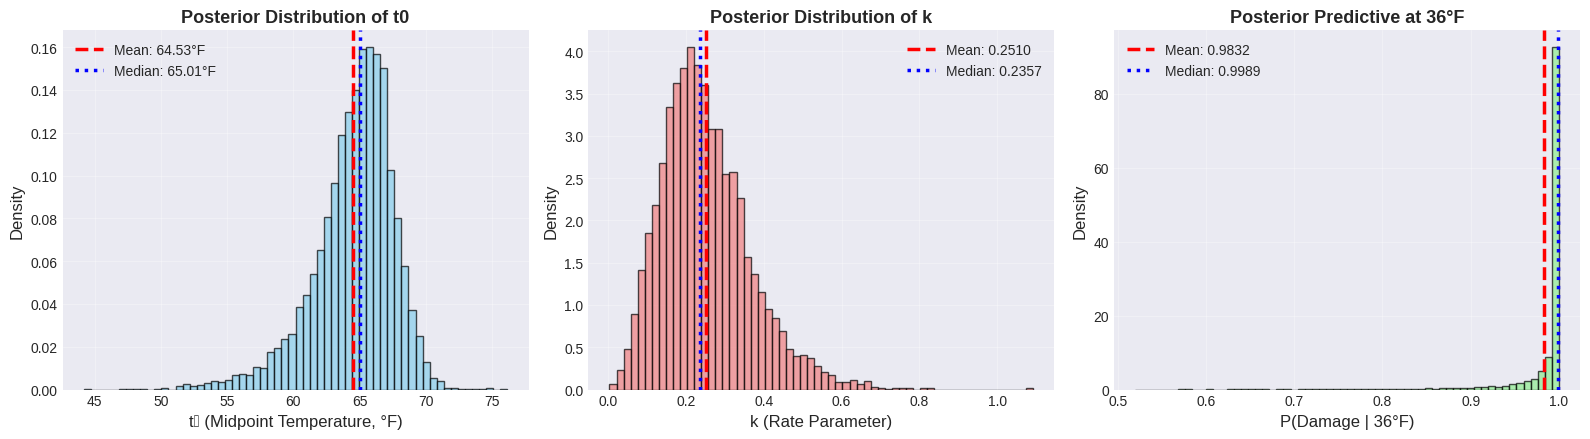

In [21]:
# Figure 4 - Posterior Distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# t0 distribution
axes[0].hist(t0_samples, bins=60, density=True, alpha=0.7, edgecolor='black', color='skyblue')
axes[0].axvline(t0_samples.mean(), color='red', linestyle='--', linewidth=2.5,
               label=f'Mean: {t0_samples.mean():.2f}°F')
axes[0].axvline(np.median(t0_samples), color='blue', linestyle=':', linewidth=2.5,
               label=f'Median: {np.median(t0_samples):.2f}°F')
axes[0].set_xlabel('t₀ (Midpoint Temperature, °F)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Posterior Distribution of t0', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# k distribution
axes[1].hist(k_samples, bins=60, density=True, alpha=0.7, edgecolor='black', color='lightcoral')
axes[1].axvline(k_samples.mean(), color='red', linestyle='--', linewidth=2.5,
               label=f'Mean: {k_samples.mean():.4f}')
axes[1].axvline(np.median(k_samples), color='blue', linestyle=':', linewidth=2.5,
               label=f'Median: {np.median(k_samples):.4f}')
axes[1].set_xlabel('k (Rate Parameter)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Posterior Distribution of k', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# P(damage at 36°F) distribution
axes[2].hist(p_damage_36, bins=60, density=True, alpha=0.7, edgecolor='black', color='lightgreen')
axes[2].axvline(mean_prob, color='red', linestyle='--', linewidth=2.5,
               label=f'Mean: {mean_prob:.4f}')
axes[2].axvline(median_prob, color='blue', linestyle=':', linewidth=2.5,
               label=f'Median: {median_prob:.4f}')
axes[2].set_xlabel('P(Damage | 36°F)', fontsize=12)
axes[2].set_ylabel('Density', fontsize=12)
axes[2].set_title('Posterior Predictive at 36°F', fontweight='bold', fontsize=13)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('Figure4_Posterior_Distributions.png', dpi=300, bbox_inches='tight')
plt.show()



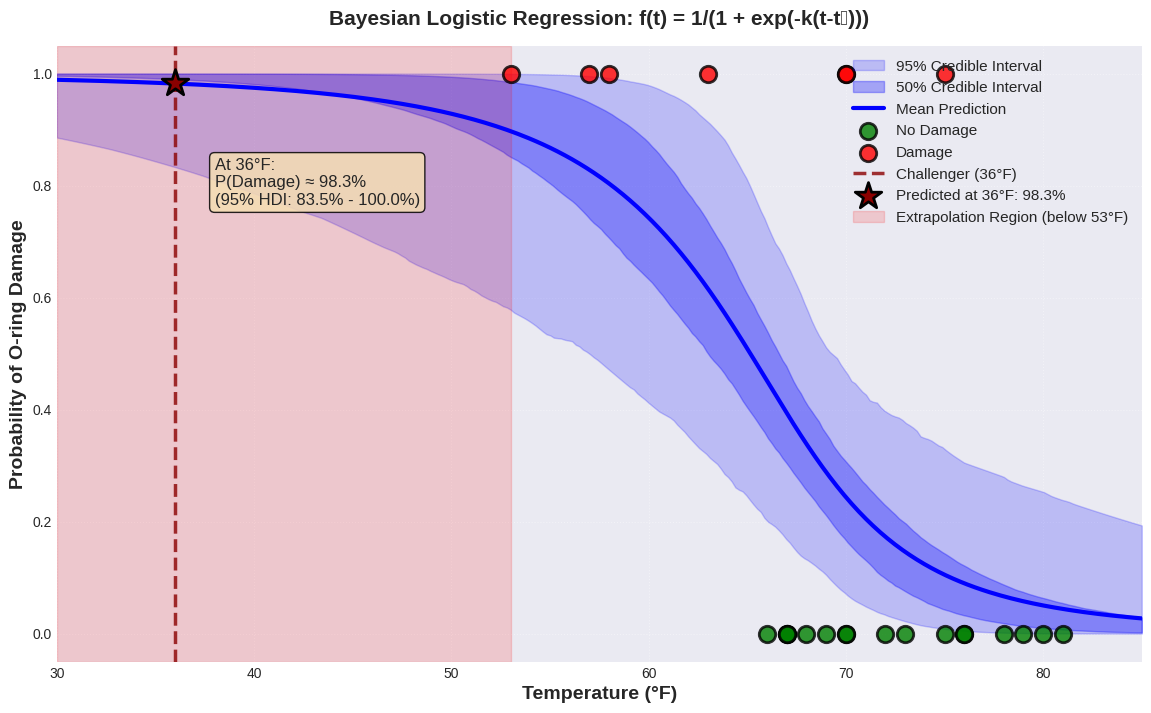

In [23]:
# Figure 5 - Fitted Logistic Regression Model
temp_range = np.linspace(30, 85, 300)

# Sample posterior predictions
n_samples = 1000
sample_idx = np.random.choice(len(t0_samples), n_samples, replace=False)
predictions = np.zeros((n_samples, len(temp_range)))

for i, idx in enumerate(sample_idx):
    logit_p = -k_samples[idx] * (temp_range - t0_samples[idx])
    predictions[i] = 1 / (1 + np.exp(-logit_p))

pred_mean = predictions.mean(axis=0)
pred_lower = np.percentile(predictions, 2.5, axis=0)
pred_upper = np.percentile(predictions, 97.5, axis=0)
pred_25 = np.percentile(predictions, 25, axis=0)
pred_75 = np.percentile(predictions, 75, axis=0)

plt.figure(figsize=(14, 8))
plt.fill_between(temp_range, pred_lower, pred_upper, alpha=0.2, color='blue',
                label='95% Credible Interval')
plt.fill_between(temp_range, pred_25, pred_75, alpha=0.3, color='blue',
                label='50% Credible Interval')
plt.plot(temp_range, pred_mean, 'b-', linewidth=3, label='Mean Prediction', zorder=4)

# Observed data
plt.scatter(temperature[damage==0], damage[damage==0], alpha=0.8, s=140,
           edgecolors='black', linewidth=2, color='green', label='No Damage', zorder=5)
plt.scatter(temperature[damage==1], damage[damage==1], alpha=0.8, s=140,
           edgecolors='black', linewidth=2, color='red', label='Damage', zorder=5)

# Highlight 36°F
plt.axvline(36, color='darkred', linestyle='--', linewidth=2.5, alpha=0.8,
           label='Challenger (36°F)', zorder=3)
plt.scatter([36], [mean_prob], s=400, color='darkred', marker='*',
           edgecolors='black', linewidth=2, zorder=6,
           label=f'Predicted at 36°F: {mean_prob:.1%}')

# Shaded extrapolation region
plt.axvspan(30, temperature.min(), alpha=0.15, color='red',
           label=f'Extrapolation Region (below {temperature.min()}°F)')

plt.xlabel('Temperature (°F)', fontsize=14, fontweight='bold')
plt.ylabel('Probability of O-ring Damage', fontsize=14, fontweight='bold')
plt.title('Bayesian Logistic Regression: f(t) = 1/(1 + exp(-k(t-t₀)))',
         fontsize=15, fontweight='bold', pad=15)
plt.legend(fontsize=11, loc='upper right', framealpha=0.95)
plt.grid(True, alpha=0.4, linestyle=':', linewidth=0.8)
plt.ylim(-0.05, 1.05)
plt.xlim(30, 85)

textstr = f'At 36°F:\nP(Damage) ≈ {mean_prob:.1%}\n(95% HDI: {hdi_low:.1%} - {hdi_high:.1%})'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.85)
plt.text(38, 0.85, textstr, fontsize=12, verticalalignment='top', bbox=props)

#plt.tight_layout()
#plt.savefig('Figure5_Fitted_Model.png', dpi=300, bbox_inches='tight')
plt.show()

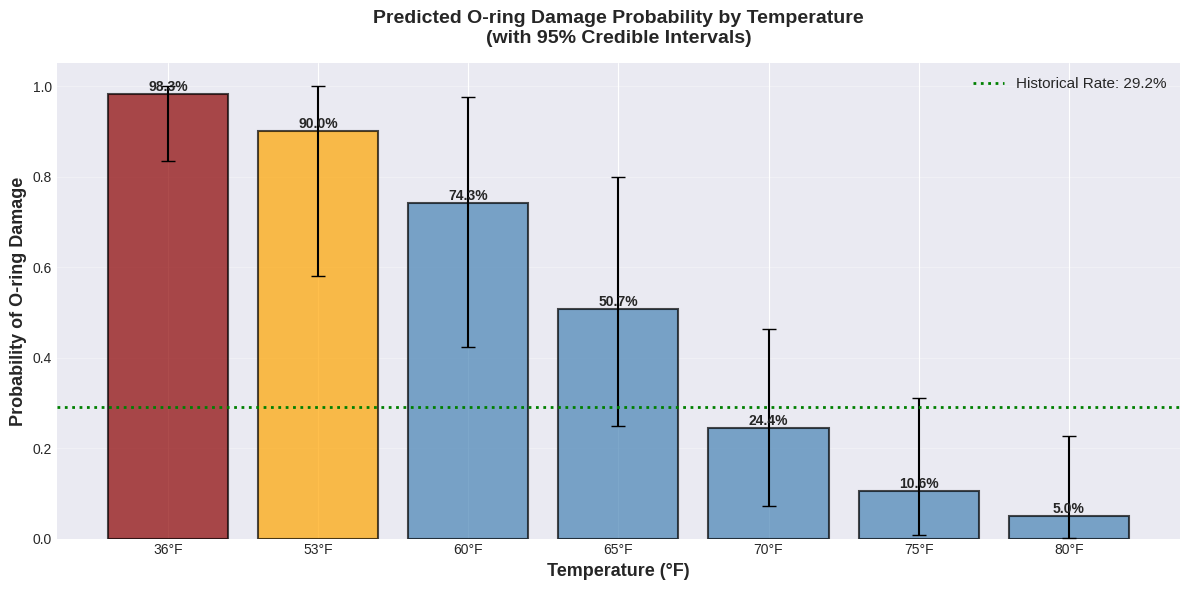

In [24]:
# Figure 6 - Risk Comparison Bar Chart
temps_to_plot = [36, 53, 60, 65, 70, 75, 80]
means = [temp_comparison[t][0] for t in temps_to_plot]
lows = [temp_comparison[t][1] for t in temps_to_plot]
highs = [temp_comparison[t][2] for t in temps_to_plot]
errors_low = [means[i] - lows[i] for i in range(len(means))]
errors_high = [highs[i] - means[i] for i in range(len(means))]

colors = ['darkred' if t == 36 else 'orange' if t < 60 else 'steelblue'
         for t in temps_to_plot]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(temps_to_plot)), means,
               yerr=[errors_low, errors_high],
               capsize=5, alpha=0.7, color=colors,
               edgecolor='black', linewidth=1.5)

plt.xticks(range(len(temps_to_plot)), [f'{t}°F' for t in temps_to_plot])
plt.ylabel('Probability of O-ring Damage', fontsize=13, fontweight='bold')
plt.xlabel('Temperature (°F)', fontsize=13, fontweight='bold')
plt.title('Predicted O-ring Damage Probability by Temperature\n(with 95% Credible Intervals)',
         fontsize=14, fontweight='bold', pad=15)
plt.axhline(damage.mean(), color='green', linestyle=':', linewidth=2,
           label=f'Historical Rate: {damage.mean():.1%}')
plt.grid(True, alpha=0.3, axis='y')
plt.legend(fontsize=11)

for i, (bar, mean) in enumerate(zip(bars, means)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{mean:.1%}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
#plt.savefig('Figure6_Risk_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1000x800 with 0 Axes>

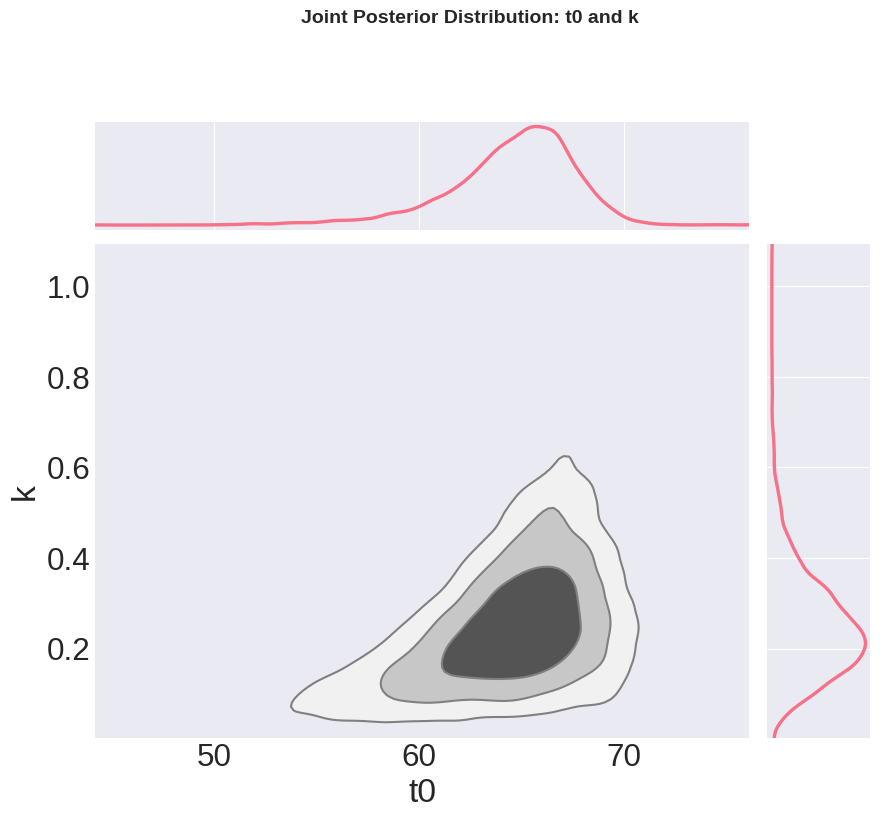

In [26]:
# Figure7 - Joint Posterior Distribution
fig = plt.figure(figsize=(10, 8))
az.plot_pair(
    trace,
    var_names=['t0', 'k'],
    kind='kde',
    marginals=True,
    figsize=(10, 8)
)
plt.suptitle('Joint Posterior Distribution: t0 and k',
            fontsize=14, fontweight='bold', y=1.02)
#plt.tight_layout()
plt.savefig('Figure7_Joint_Posterior.png', dpi=300, bbox_inches='tight')
plt.show()